# **Practicing with Python**

<mark>**Exercise 1**</mark></br>
Draw the graph of the function $y=\sin(x^2)$ for $x\in[0,2\pi]$.

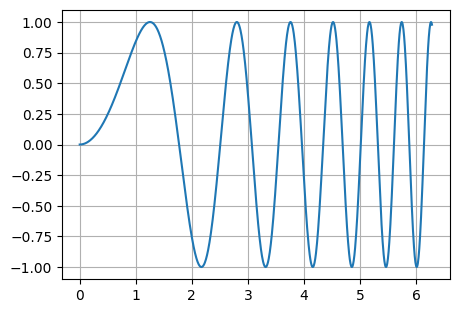

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2*np.pi, 1000)
plt.figure(figsize = (5, 3.5))
plt.plot(x, np.sin(x**2))
plt.grid()
plt.show()

<mark>**Exercise 2**</mark></br>
Write a function called $\texttt{num2p}$ that, given a numerical value $x$, returns a string with its percentage representation. That is:

    num2p(0.57) --> '57.00%'
    num2p(0.011) --> '1.10%'

In [2]:
def num2p(x):
  return ("%.2f" % (100*x)) + "%"

num2p(0.011)

'1.10%'

<mark>**Exercise 3**</mark></br>
Write a function called $\texttt{Jacobian}$ that, given two values $x$ and $y$, returns the matrix

$$J = \left[\begin{array}{cc}\sin(y)e^x & \cos(y)e^x \\ 2x-1 & 0\end{array}\right].$$

In [3]:
import numpy as np

def Jacobian(x, y):
  return np.array([[np.sin(y)*np.exp(x),  np.cos(y)*np.exp(x)],
                   [2*x-1,                0                  ]])

<mark>**Exercise 4**</mark></br>
Define a function called $\texttt{randomStep}$ that, given a value $x$, returns $x+\delta$, with $\delta$ being a random value between -1 and 1. Try then callind "randomStep(0)" several times, as to verify that the output changes from time to time.

*Hint: exploit the function numpy.random.rand, which generates a random value in [0,1].*

In [4]:
import numpy as np

def randomStep(x):
  return x + 2*np.random.rand()-1

print(randomStep(0))
print(randomStep(0))
print(randomStep(0))
print(randomStep(0))

0.6569689460257981
0.3620136983299558
-0.17890968064701207
0.27919809052979416


<mark>**Exercise 5**</mark></br>
Let's say we would like to use the function at Ex. 4 to construct a *random walk*, that is: starting from a given $x_{0}\in\mathbb{R}$, we define

<p align="center">
$x_{1}=\texttt{randomStep}(x_{0}),$
</p>

then $x_{2}=$ randomStep($x_{1}$) and so on. In general, one can prove that, at some point $|x_{n}|\ge10$ for some $n$. Given the stochasticity of the system, however, this event can happen immediately or after some time.
 </br>
 </br>
 Write a function called $\texttt{waitingTime}$ that, given $x_{0}$, returns the first $n$ for which $|x_{n}|\ge10.$ Verify that, even when starting from a fixed $x_{0}$, the value of such $n$ is still random.

In [5]:
def waitingTime(x0):
  x = x0
  n = 0
  while(abs(x)<10):
    x = randomStep(x)
    n = n+1
  return n

print(waitingTime(0))
print(waitingTime(0))
print(waitingTime(0))

216
113
338


<mark>**Exercise 6**</mark></br>
Crate a function called $\texttt{find}$ that, given a vector $\mathbf{v}$ (1D numpy.array) and a value $x$, returns the first index $i$ for which the $i$th entry of $\mathbf{v}$ equals $x$. If $x$ does not appear among the elements in $\mathbf{v}$, the function should raise an error. Namely,

    v = np.array([1,2,0,4,-1,0,8])
    find(v, 0) ---> 2
   
    v = np.array([3,-2,5,4])
    find(v, 0) ---> ERROR: the vector does not contain the required value.

*Hint 1: carefull with machine precision! To make thigs "more precisely", instead of using "==" try using the function numpy.isclose (with default values, or using a tollerance of your choice).*

*Hint 2: to raise a Python error, rather than simply printing something, you can use the syntax*

    raise RuntimeError('ERROR: the vector does not contain the required value.')

In [6]:
import numpy as np
print(np.isclose(3, 4))
print(np.isclose(1, 1.000000000000000000000000000000000000001))

False
True


In [7]:
# Solution using a WHILE loop
def find(v, x):
  i = 0
  found = False
  while(  (not found) and (i<len(v))   ):
    found = np.isclose(v[i], x)
    i = i+1

  if(found):
    return i-1
  else:
    raise RuntimeError('ERROR: the vector does not contain the required value.')

v = np.array([1,2,0,4,-1,0,8])
find(v, 0)

2

In [8]:
# Solution without loop
def find(v, x):
  i = np.abs(v-x).argmin() # index of the v-component closest to x (if they are equal, we return "i", otherwise we raise an error)
  if(np.isclose(v[i], x)):
    return i
  else:
    raise RuntimeError('ERROR: the vector does not contain the required value.')

v = np.array([1,2,0,4,-1,0,8])
find(v, 0)

2

<mark>**Exercise 7**</mark></br>
Draw the unit circle.

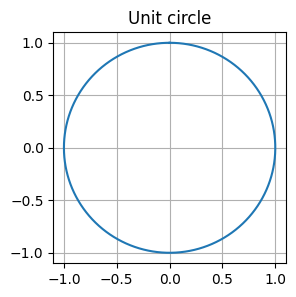

In [9]:
import numpy as np
import matplotlib.pyplot as plt
theta = np.linspace(0.0, 2*np.pi, 1000)

plt.figure(figsize = (3,3))
plt.title("Unit circle")
plt.plot(np.sin(theta), np.cos(theta))
plt.grid()
plt.show()

<mark>**Exercise 8**</mark></br>
Write a function called $\texttt{minij}$ that, given a matrix

$$\mathbf{A}=\left[\begin{array}{cccc}a_{1,1} & ... & a_{1,p}\\.. & ... & ...\\a_{d,1} & ... & a_{d,p}\end{array}\right]$$

returns the indexes $i,j$ corresponding to the smallest value in $\mathbf{A}$.

*Hint: there are at least two approaches. The first one, is to run a double for loop, scanning all the elements in the matrix. The second one, which is more "numpy-style", is to exploit the functions **numpy.argmin** and **numpy.unravel_index** (to figure out how they work, use the help commend and/or mess around with them a little). In general, the second approach is far more efficient (furthermore, it can be implemented using a single line of code!).*

In [10]:
import numpy as np

def minij(A):
  return np.unravel_index(np.argmin(A), A.shape)

<mark>**Exercise 9**</mark></br>
Write a function called $\texttt{closestOnes}$ that, given two arrays $\mathbf{x}=[x_{1},\dots,x_{d}],\;\mathbf{y}=[y_{1},\dots,y_{p}]$, returns the two entries $x_{i}$ ed $y_{j}$ which are closest, in the sense that $|x_i-y_j|$ is minimal. In other words:

     closestOnes([5.0, 7.0, -2.3, 1.4], [4.1, 0.0]) --> 5.0, 4.1
     closestOnes([0.0, 1.9, 3.0, 8.3], [9.0, 5.0, -1.7]) --> 8.3, 9.0

*Hint: if x and y are 1D numpy.arrays, try computing x.reshape(-1,1)  - y.reshape(1,-1). What do you get? Can you exploit this, maybe in conjunction with the function defined in Ex. 8?*

In [11]:
def closestOnes(X, Y):
  x, y = np.array(X), np.array(Y)

  d, p = len(x), len(y)
  diffs = np.abs(x.reshape(-1,1)-y.reshape(1,-1))  # matrix d x p containing the differences (in absolute value) between x_i and y_j

  i, j = minij(diffs)
  return x[i], y[j]

In [12]:
closestOnes([5.0, 7.0, -2.3, 1.4], [4.1, 0.0])

(5.0, 4.1)

In [13]:
closestOnes([0.0, 1.9, 3.0, 8.3], [9.0, 5.0, -1.7])

(8.3, 9.0)

<mark>**Exercise 10**</mark></br>
Write a function called $\texttt{plotSquare}$ that, given $x,y,h$ and a string $c$, draws a square with vertices

$$\begin{array}{lll}A=(x,y), & & B = (x+h, y)\\
C=(x+h,y+h),&& D = (x, y+h),\end{array}$$

coloring the inner region with the color $c$. For instance, the call:

    plt.figure(figsize = (3,3))
    plotSquare(0, 0, 1, c = 'red')
    plt.show()

should draw a red unit square, with bottom-left vertix lying at the origin.

*Hint 1: use the **fill** function in matplotlib.pyplot.*

*Hint 2: do not use plt.figure(), plt.title() and plt.show() while defining "plotSquare". If needed, these will be called by the user, as in the example above.*

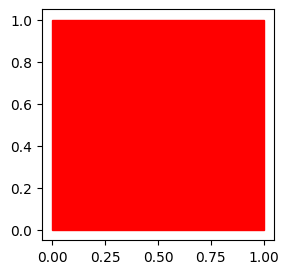

In [14]:
import matplotlib.pyplot as plt

def plotSquare(x, y, h, c = 'red'):
  plt.fill([x, x+h, x+h, x], [y, y, y+h, y+h], color = c)

plt.figure(figsize = (3,3))
plotSquare(0, 0, 1, c = 'red')
plt.show()

<mark>**Exercise 11**</mark></br>
Leveraging on the function defined in Ex. 10, draw an 8x8 chessboard.

*Hint 1: use a double FOR loop!*

*Hint 2: you can use the colors 'saddlebrown' and 'tan'. Finally, if you wish, you hide the coordinate axis with plt.axis("off").*

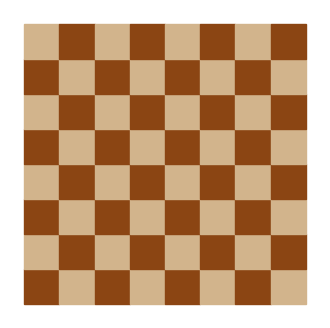

In [15]:
dark = 'saddlebrown'
light = 'tan'
colors = [dark, light]

plt.figure(figsize = (4,4))
for i in range(8):
  for j in range(8):
    index = (i+j)%2
    plotSquare(i, j, 1, c = colors[index])

plt.axis("off")
plt.show()